## Covariate patterns and TiRex2 in-context length demo

This notebook explores the per-cycle patterns of the hydraulic dataset's
covariates, picks one with a visually distinct single-cycle waveform, and
shows how TiRex2's forecast quality improves as more repeated cycles are
given as context.

### Load data

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data_hydraulic")
SENSOR_SAMPLE_RATES = {  # Hz, i.e. columns per 60s cycle / 60
    "PS1": 100, "PS2": 100, "PS3": 100, "PS4": 100, "PS5": 100, "PS6": 100,
    "EPS1": 100,
    "FS1": 10, "FS2": 10,
    "TS1": 1, "TS2": 1, "TS3": 1, "TS4": 1,
    "VS1": 1, "CE": 1, "CP": 1, "SE": 1,
}


def load_sensor(name: str, data_dir=DATA_DIR) -> pd.DataFrame:
    return pd.read_csv(data_dir / f"{name}.txt", sep="\t", header=None)


# All 17 covariates available in the dataset
ALL_SENSORS = list(SENSOR_SAMPLE_RATES)
sensors = {name: load_sensor(name) for name in ALL_SENSORS}
print({name: df.shape for name, df in sensors.items()})

{'PS1': (2205, 6000), 'PS2': (2205, 6000), 'PS3': (2205, 6000), 'PS4': (2205, 6000), 'PS5': (2205, 6000), 'PS6': (2205, 6000), 'EPS1': (2205, 6000), 'FS1': (2205, 600), 'FS2': (2205, 600), 'TS1': (2205, 60), 'TS2': (2205, 60), 'TS3': (2205, 60), 'TS4': (2205, 60), 'VS1': (2205, 60), 'CE': (2205, 60), 'CP': (2205, 60), 'SE': (2205, 60)}


### Covariate pattern survey: 1 cycle

For every covariate (all 17), plot the within-cycle waveform of a single 60s
cycle. The x-axis is in seconds so sensors with different sample rates
(100 Hz, 10 Hz, 1 Hz) are directly comparable. This makes it easy to see
which covariates have a clear, distinctive shape within a cycle versus ones
that look flat or just noisy.

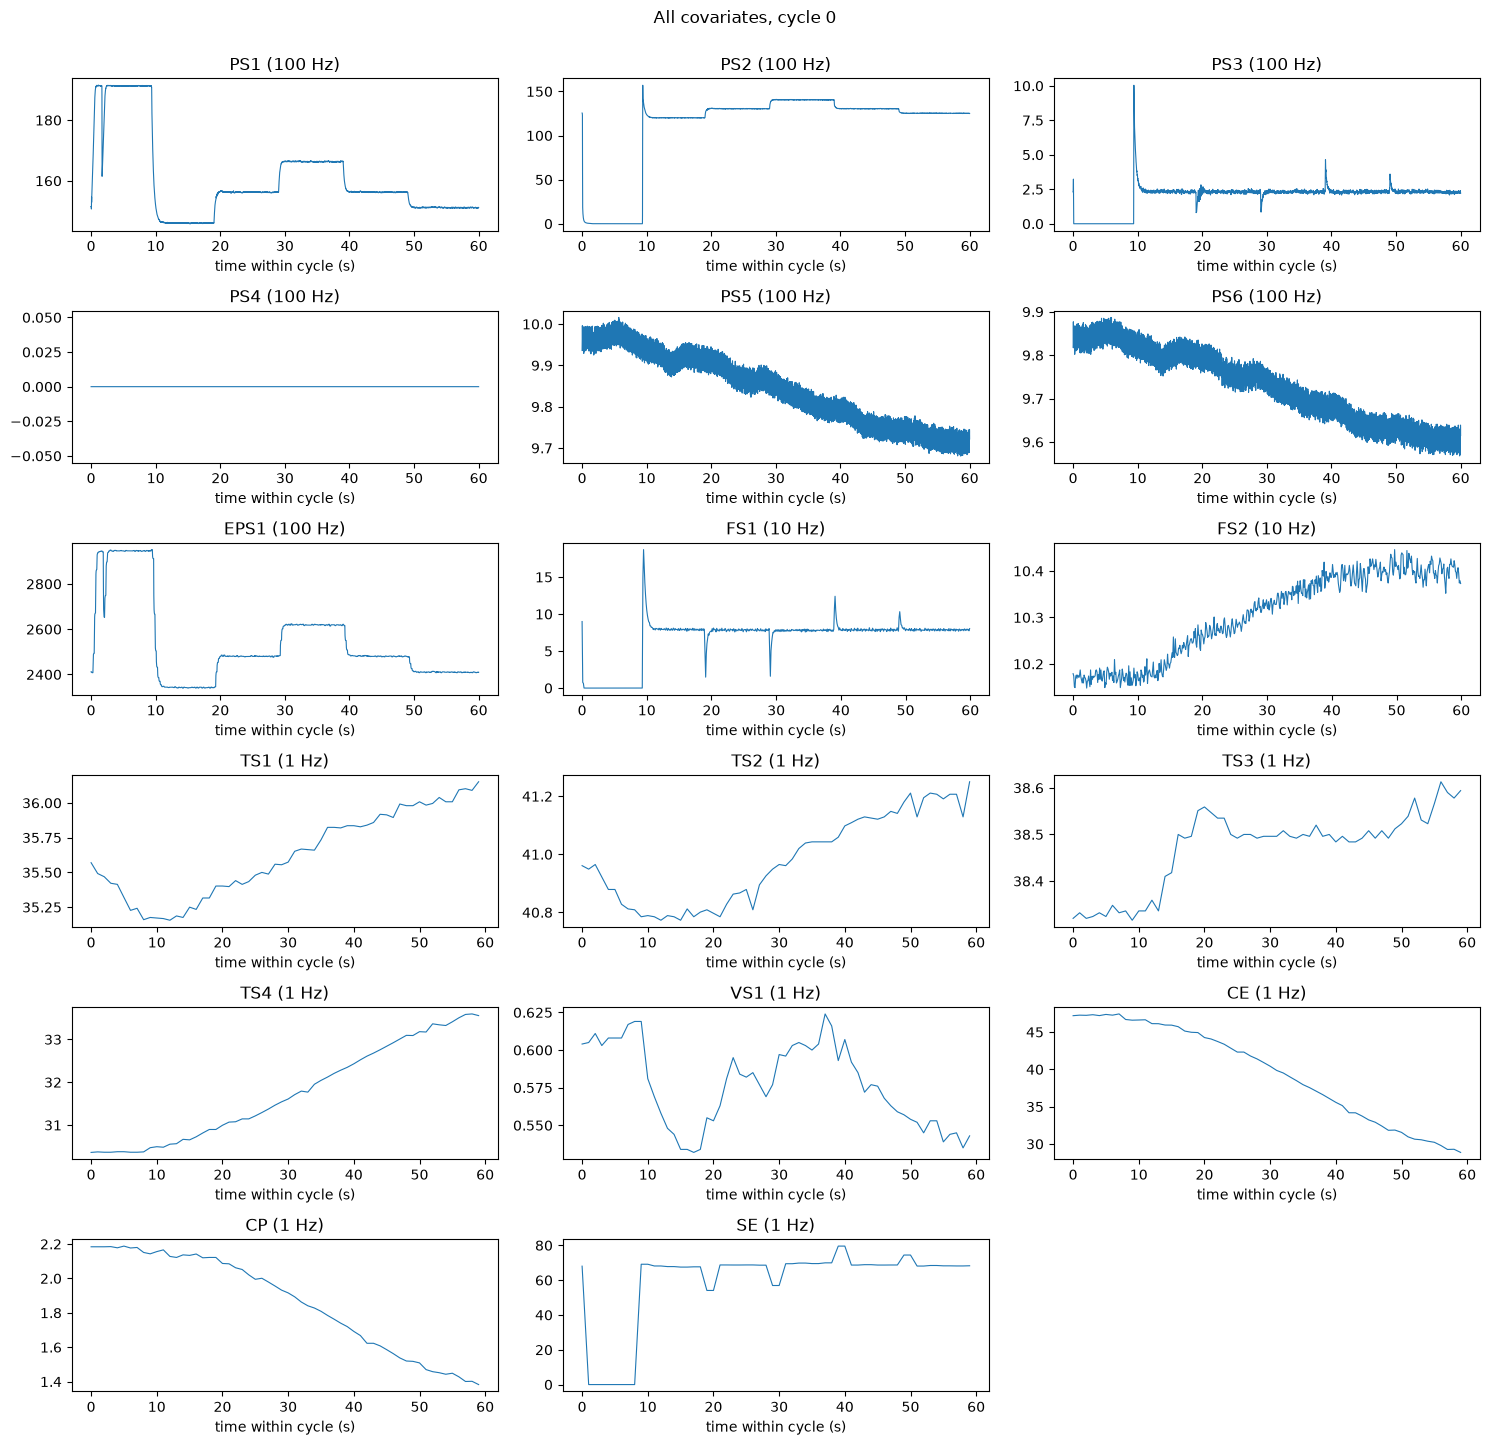

In [8]:
import numpy as np

CYCLE_TO_SHOW = 0
N_COLS = 3
n_rows = int(np.ceil(len(ALL_SENSORS) / N_COLS))

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(15, 2.4 * n_rows))
for ax, name in zip(axes.flat, ALL_SENSORS):
    values = sensors[name].iloc[CYCLE_TO_SHOW].values
    t = np.arange(len(values)) / SENSOR_SAMPLE_RATES[name]  # seconds within the cycle
    ax.plot(t, values, linewidth=0.8)
    ax.set_title(f"{name} ({SENSOR_SAMPLE_RATES[name]} Hz)")
    ax.set_xlabel("time within cycle (s)")
for ax in axes.flat[len(ALL_SENSORS):]:
    ax.axis("off")
fig.suptitle(f"All covariates, cycle {CYCLE_TO_SHOW}", y=1.0)
fig.tight_layout()
plt.show()

### Covariate pattern survey: 5 consecutive cycles

For every covariate (all 17), the plots below concatenate 5 consecutive
cycles end-to-end (dashed lines = cycle boundaries). This shows how each
sensor repeats from cycle to cycle and how it drifts over multiple cycles, so
you can judge which covariates carry a repeatable pattern and which only show
slow trends.

The forecasting demo further down uses `PS2` (pressure sensor 2), which shows a
sharp pulse: a roughly constant high pressure (~120-150 bar) for the first
part of the cycle, then a drop to near zero. Change the sensor used in that
demo if the survey below points to a better candidate.

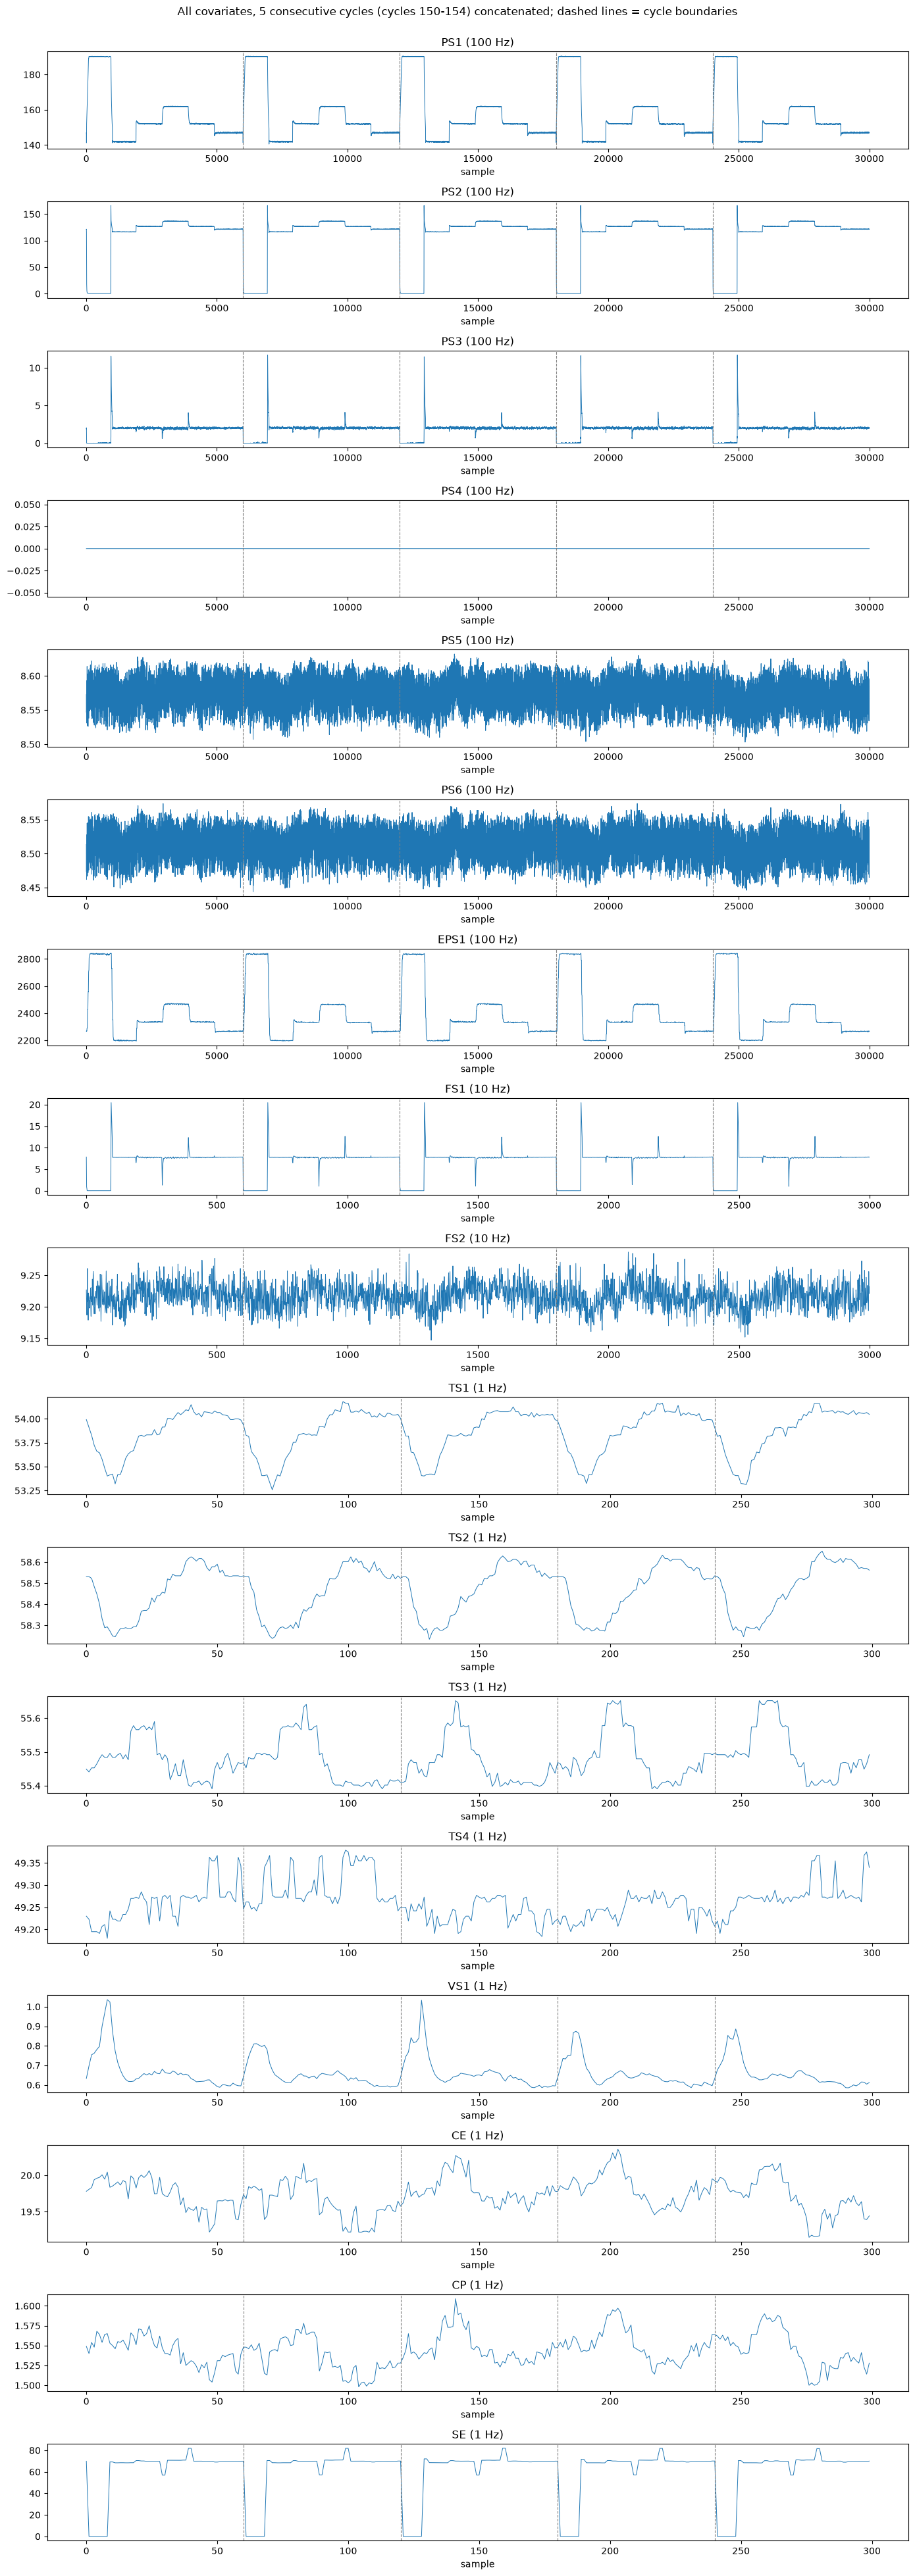

In [15]:
FIRST_CYCLE = 150
N_CYCLES = 5


fig, axes = plt.subplots(len(ALL_SENSORS), 1, figsize=(14, 2.3 * len(ALL_SENSORS)))
for ax, name in zip(axes, ALL_SENSORS):
    block = sensors[name].iloc[FIRST_CYCLE:FIRST_CYCLE + N_CYCLES].values
    cycle_len = block.shape[1]
    ax.plot(block.reshape(-1), linewidth=0.7)
    for i in range(1, N_CYCLES):
        ax.axvline(i * cycle_len, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name} ({SENSOR_SAMPLE_RATES[name]} Hz)")
    ax.set_xlabel("sample")
fig.suptitle(
    f"All covariates, {N_CYCLES} consecutive cycles (cycles {FIRST_CYCLE}-{FIRST_CYCLE + N_CYCLES - 1}) "
    "concatenated; dashed lines = cycle boundaries",
    y=1.0,
)
fig.tight_layout()
plt.show()